# Plotting mortality due to PM<sub>2.5</sub> exposure by country

Using central estimates only

In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import SymLogNorm
from matplotlib.ticker import FuncFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.utils import autosize_figure
import config
from utils.utils import require_dir, create_eu_country_map
import pathlib

In [2]:
def get_mortality(scenario, year, GBD_version):
    # === Path config ===
    MORT_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "mortality" / "gridpoint_mortality")

    file = f"Mortality_Country_sum_GBD23_{scenario}_{year}.nc"
    file_path = os.path.join(MORT_DIR, file)
    da = xr.open_dataarray(file_path)

    return da

In [3]:
GBD_version = "GBD23"
scenarios = ["H", "HL", "L", "LN", "M", "ML", "VL"]
scenario_longname = ["High", "High-to-Low", "Low", "Low-to-Negative", "Medium", "Medium-to-Low", "Very Low"]
years = [2040, 2060, 2080, 2100]

## Plotting individual years

In [4]:
def plot_mortality(da, scenario, scen_name, GBD_version, year, SAVE_DIR):
    # Create figure
    fig = plt.figure(figsize=autosize_figure(1, 1, yscale_factor=1.2))
    gs = GridSpec(1, 2, width_ratios=[15, 1])  # rows, columns

    # Map set up and design
    projection = ccrs.EuroPP()
    crs = ccrs.PlateCarree()

    country_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='10m',
        facecolor='none')

    # Use log scale for normalization
    vmax = da.max().item()
    cmap = plt.get_cmap("viridis")

    # Define a linear threshold region around zero
    linthresh = 1

    norm = SymLogNorm(linthresh=linthresh, vmin=0, vmax=vmax, base=10)

    # First panel
    ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)

    cb = da.plot(
        ax=ax,
        transform=crs,
        add_colorbar=False,
        cmap=cmap,
        norm=norm,
    )
    ax.add_feature(country_borders, edgecolor='white', alpha=0.5, linewidth=0.75)

    plt.title(f"{scen_name} {year}")

    # First colorbar
    cax = fig.add_subplot(gs[0, 1])
    col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
    col_bar.set_label("Total PM$_{2.5}$ Mortality year$^{-1}$)", fontsize=13)

    # Ticks
    formatter = FuncFormatter(lambda v, _: f"{v:g}")
    col_bar.ax.xaxis.set_major_formatter(formatter)

    # Define custom ticks
    ticks = [0, 1, 10, 100, 1000]

    col_bar.set_ticks(ticks)
    col_bar.ax.yaxis.set_major_formatter(formatter)

    plt.tight_layout()

    out_file = f"EU_mortality_pm25_per_country_{GBD_version}_{scenario}_{year}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path, dpi=300)
    return

In [5]:
MASKS_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "BMR" / "masks" / "country", "country masks")
SAVE_DIR = require_dir(pathlib.Path(config.PLOTTING_ROOT) / "mortality" / "pm25" / "yearly")

for scenario, scen_name in zip(scenarios, scenario_longname):
    for year in years:
        da = get_mortality(scenario, year, GBD_version)
        # get eu map by country
        da_map = create_eu_country_map(da, MASKS_DIR)
        # Plotting
        plt.rcParams.update({'font.size': 16})
        plot_mortality(da_map, scenario, scen_name, GBD_version, year, SAVE_DIR)
        plt.close()

## Plotting 2x2 per scenario

In [8]:
def plot_mortality_grid(das, scenario, scen_name, GBD_version, years, SAVE_DIR):
    fig = plt.figure(figsize=autosize_figure(2, 2, yscale_factor=1.3))
    # 2 rows x 2 map columns + 1 narrow colorbar column spanning both rows
    gs = GridSpec(2, 3, width_ratios=[15, 15, 1], height_ratios=[1, 1])

    projection = ccrs.EuroPP()
    crs = ccrs.PlateCarree()
    country_borders = cfeature.NaturalEarthFeature(
        category='cultural', name='admin_0_boundary_lines_land',
        scale='10m', facecolor='none')

    cmap = plt.get_cmap("viridis")
    # Shared scale across all four years — computed once from the global max
    vmax = max(da.max().item() for da in das)
    norm = SymLogNorm(linthresh=1, vmin=0, vmax=vmax, base=10)

    positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
    for (r, c), da, year in zip(positions, das, years):
        ax = fig.add_subplot(gs[r, c], projection=projection, frameon=True)
        cb = da.plot(ax=ax, transform=crs, add_colorbar=False, cmap=cmap, norm=norm)
        ax.add_feature(country_borders, edgecolor='white', alpha=0.5, linewidth=0.75)
        ax.set_title(f"{year}")

    fig.suptitle(f"{scen_name}", y=0.98)

    # Shared colorbar spanning both rows
    cax = fig.add_subplot(gs[:, 2])
    col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
    col_bar.set_label("Total PM$_{2.5}$ Mortality year$^{-1}$)", fontsize=16)
    formatter = FuncFormatter(lambda v, _: f"{v:g}")
    ticks = [0, 1, 10, 100, 1000]
    col_bar.set_ticks(ticks)
    col_bar.ax.yaxis.set_major_formatter(formatter)

    plt.tight_layout()
    out_file = f"EU_mortality_pm25_per_country_{GBD_version}_{scenario}_grid.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path, dpi=300)

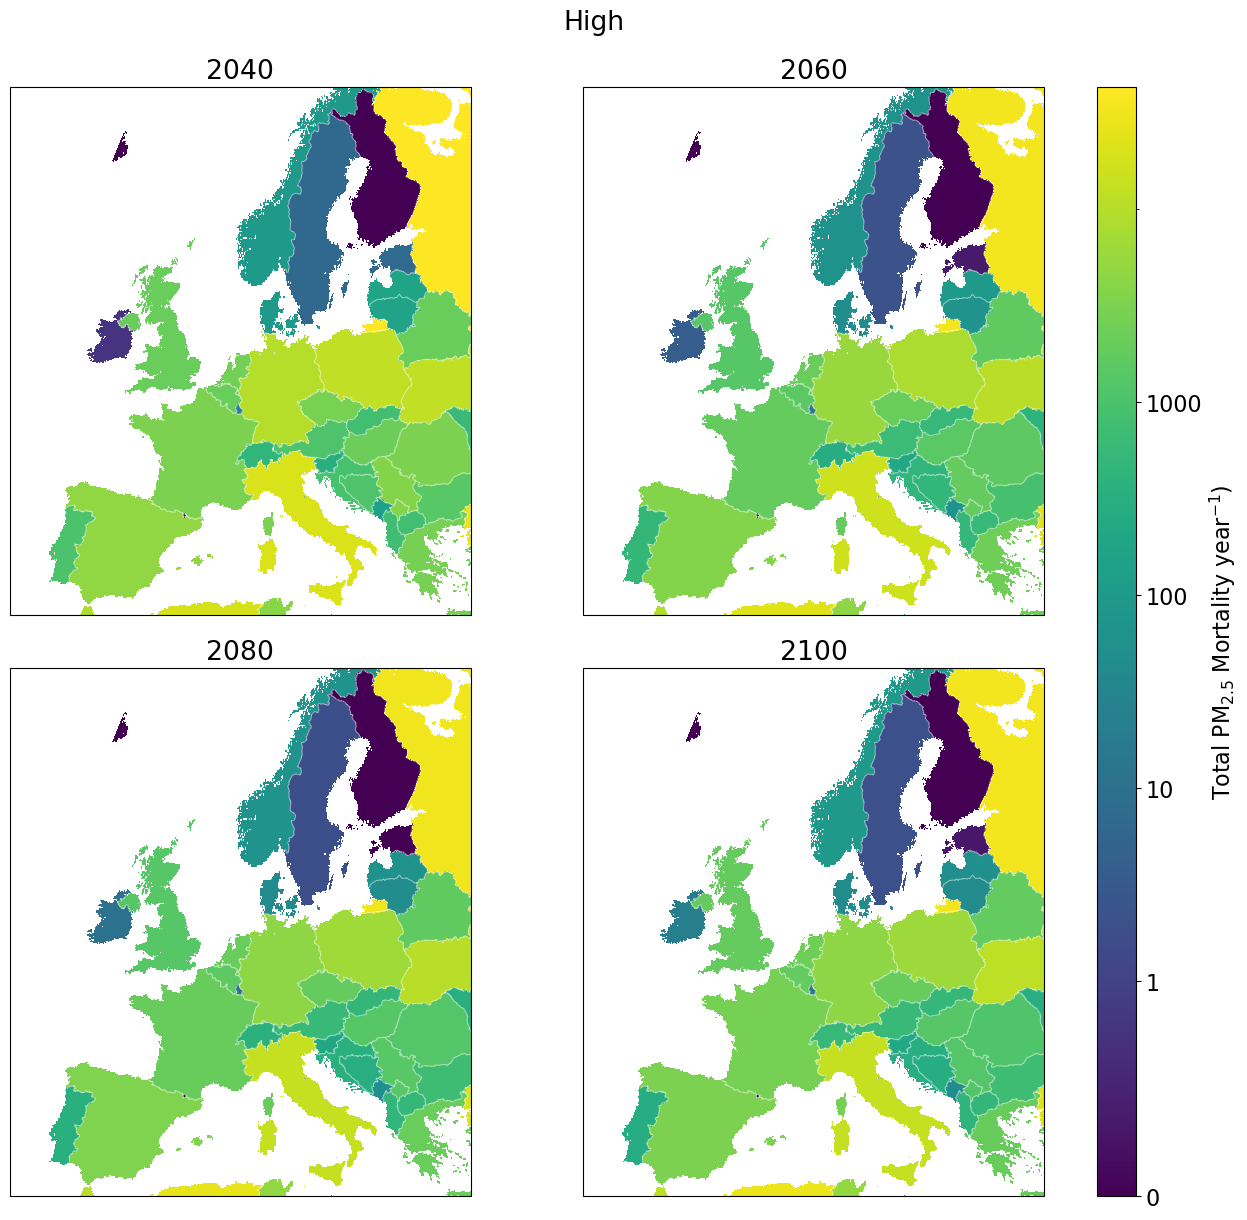

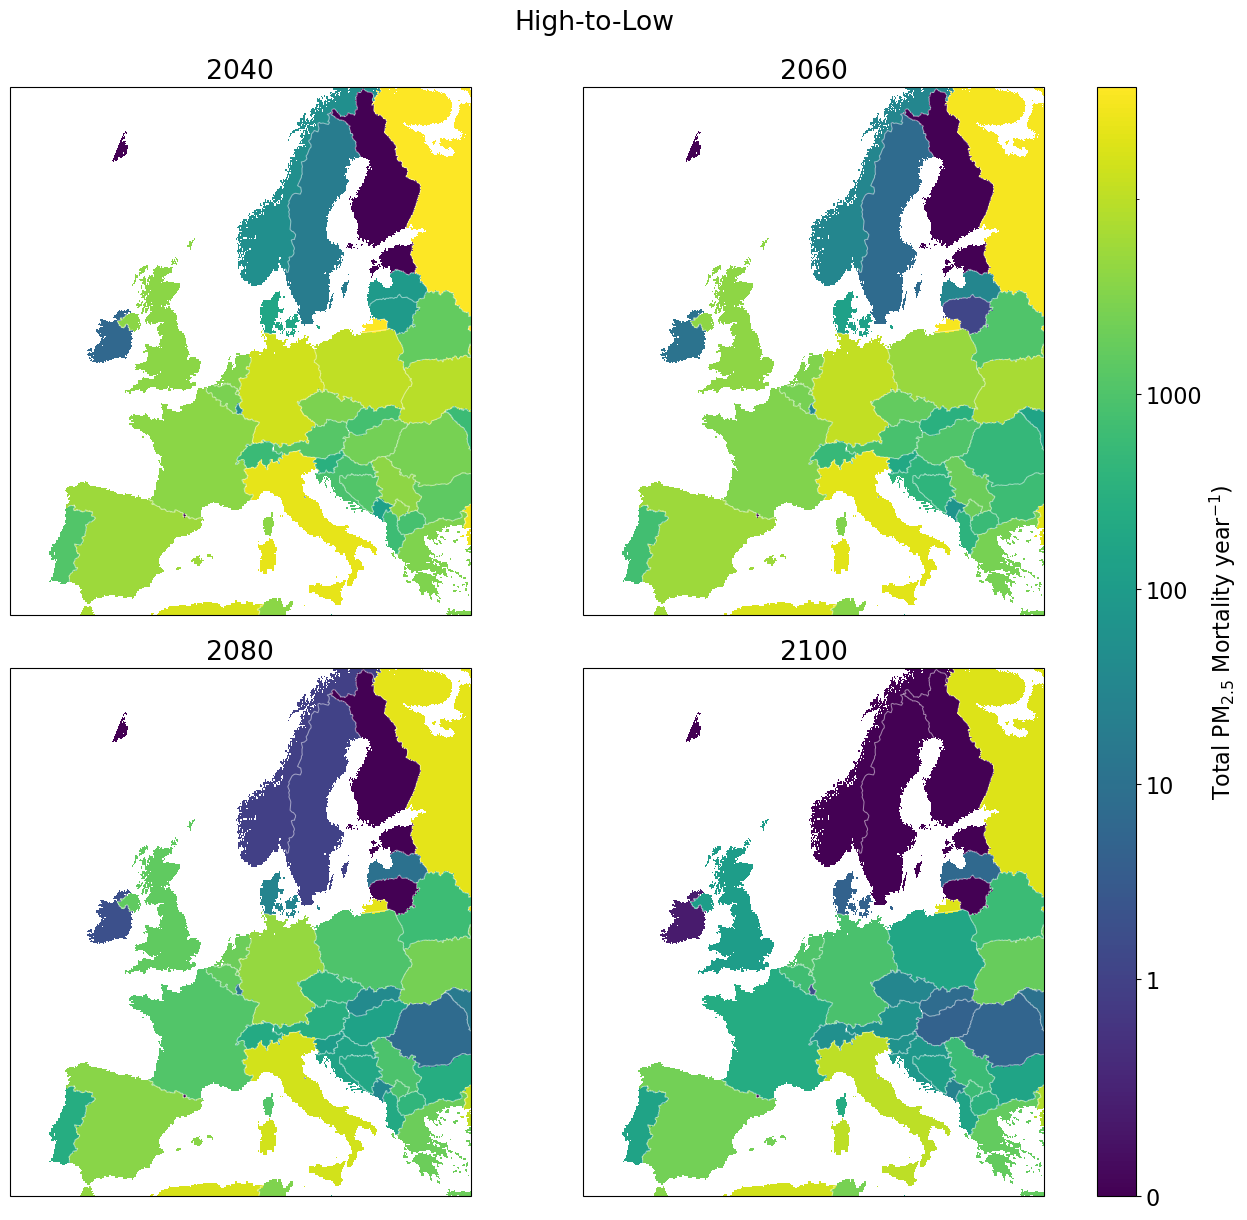

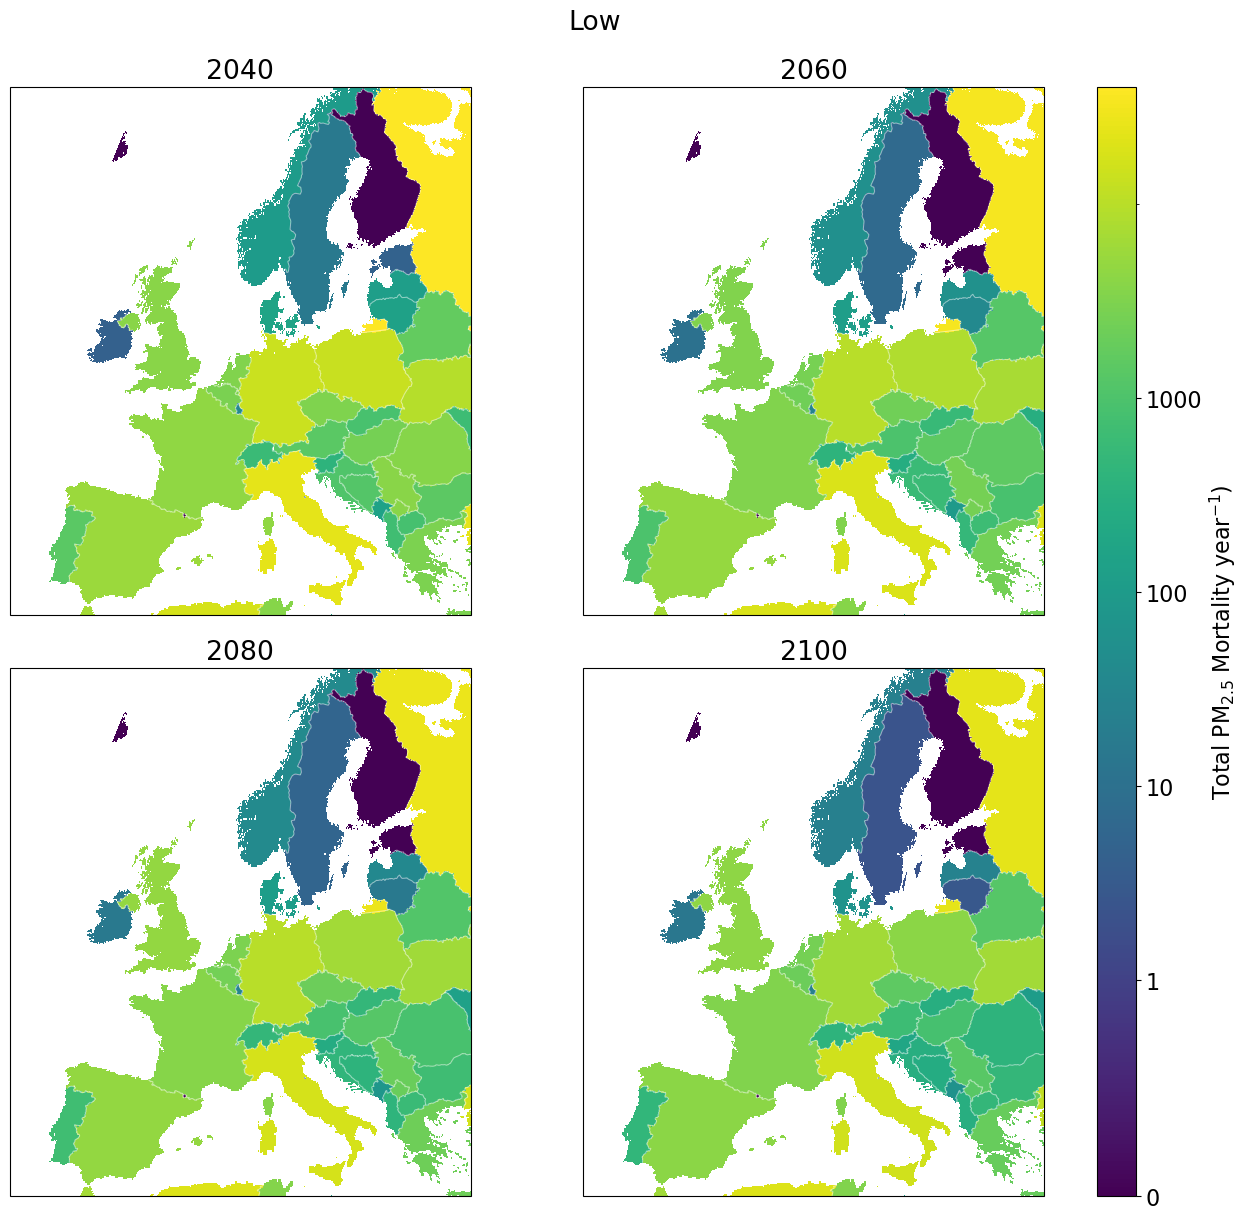

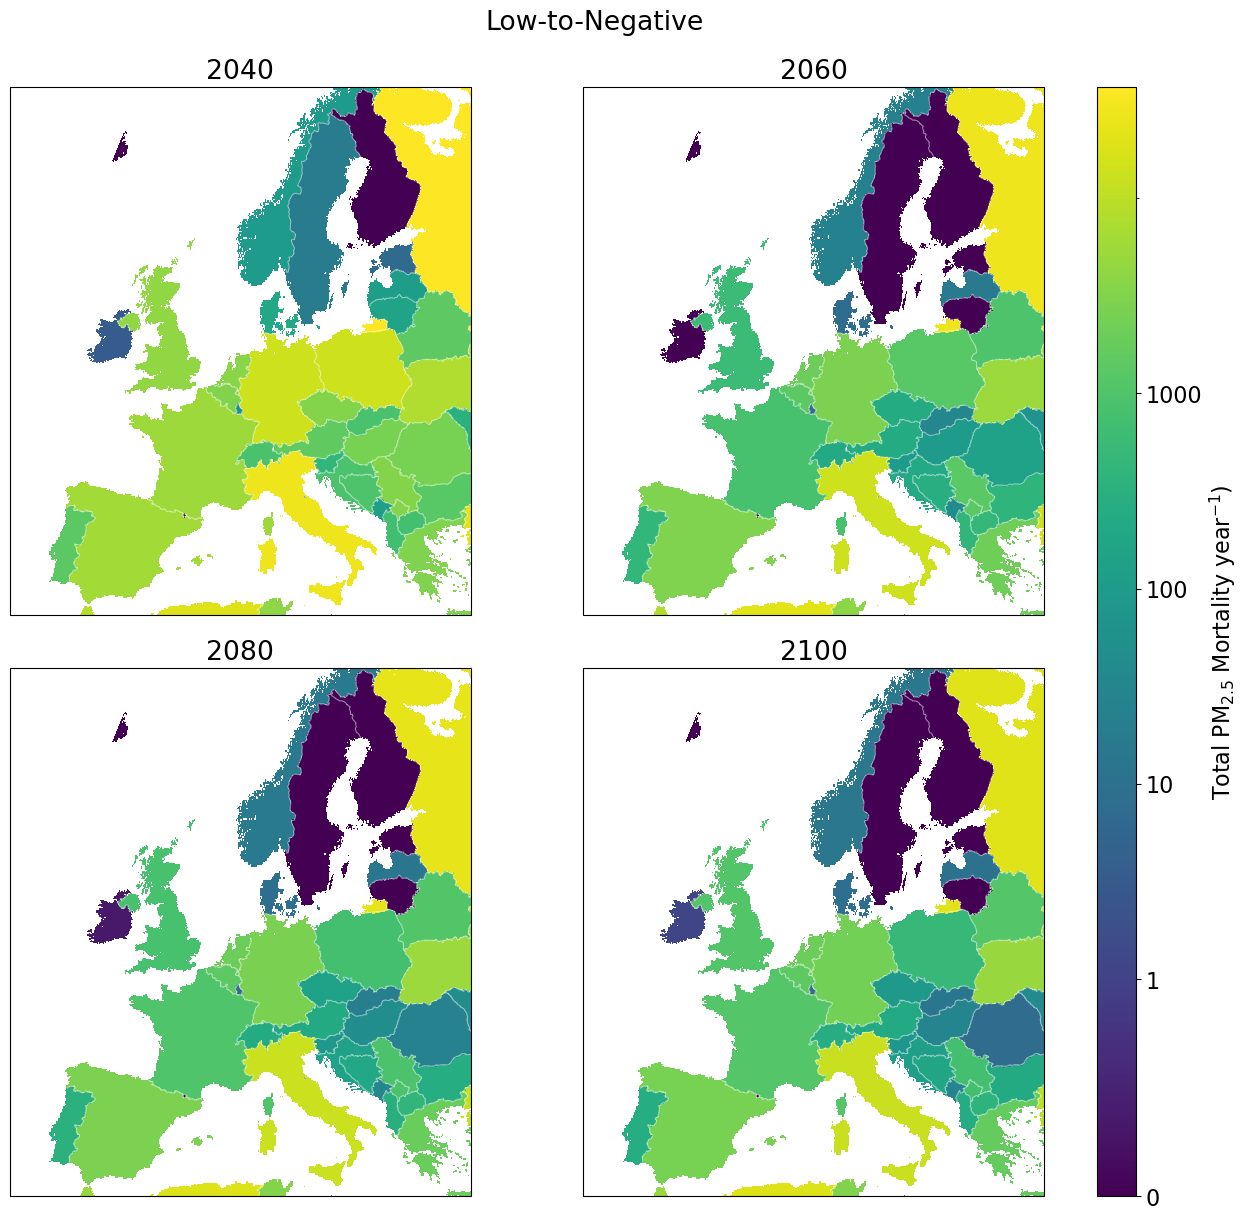

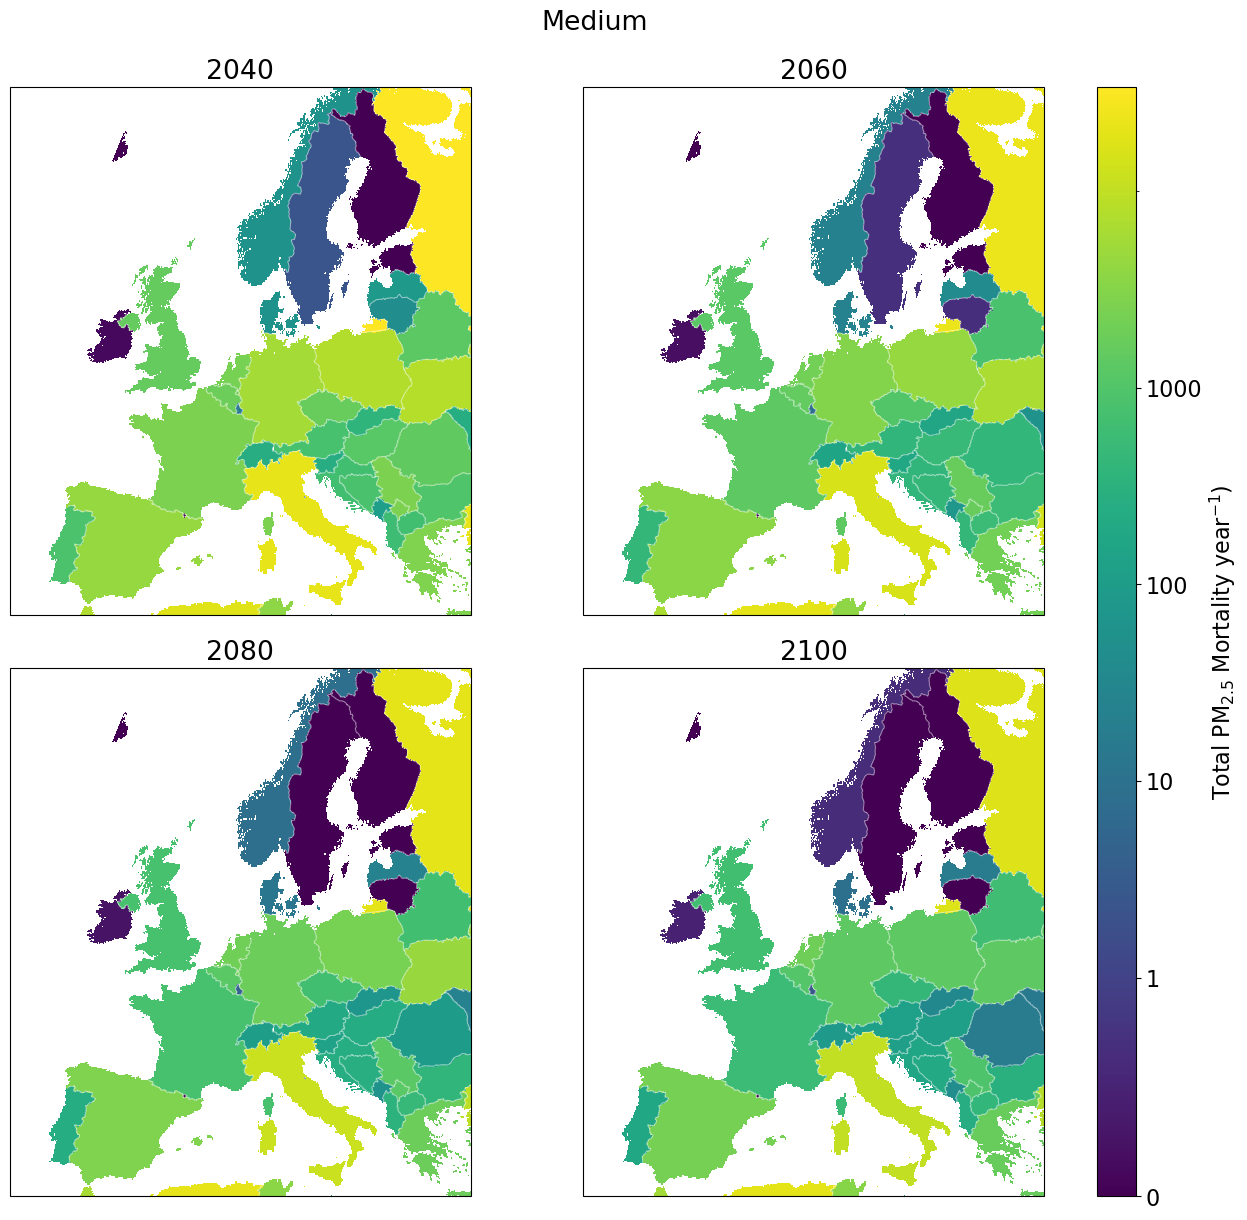

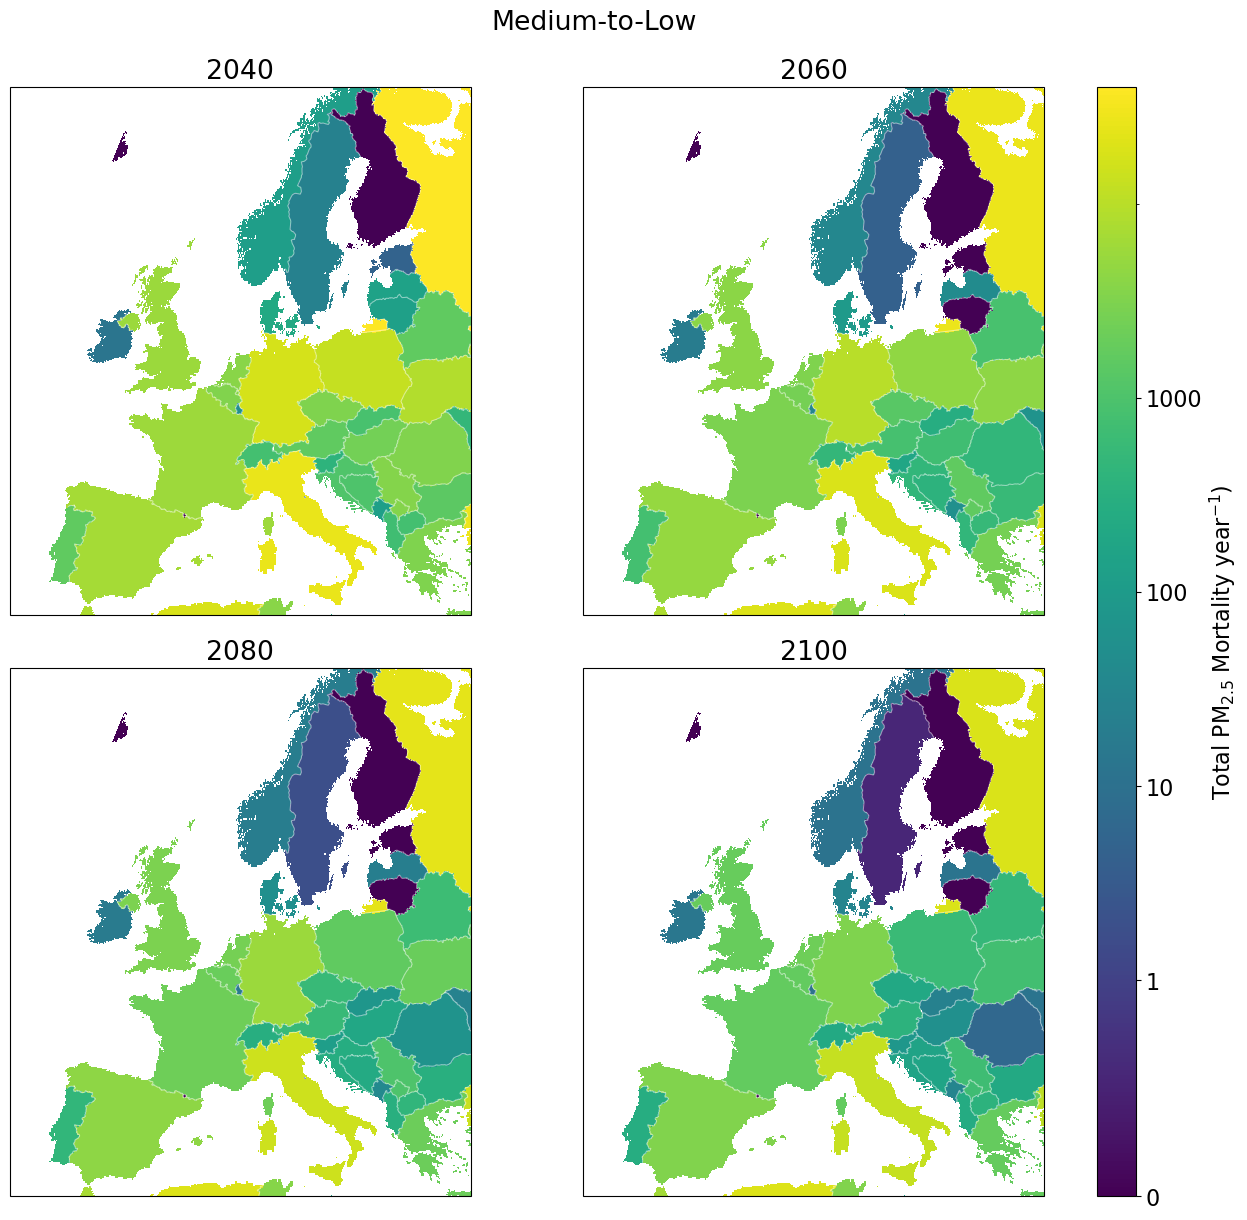

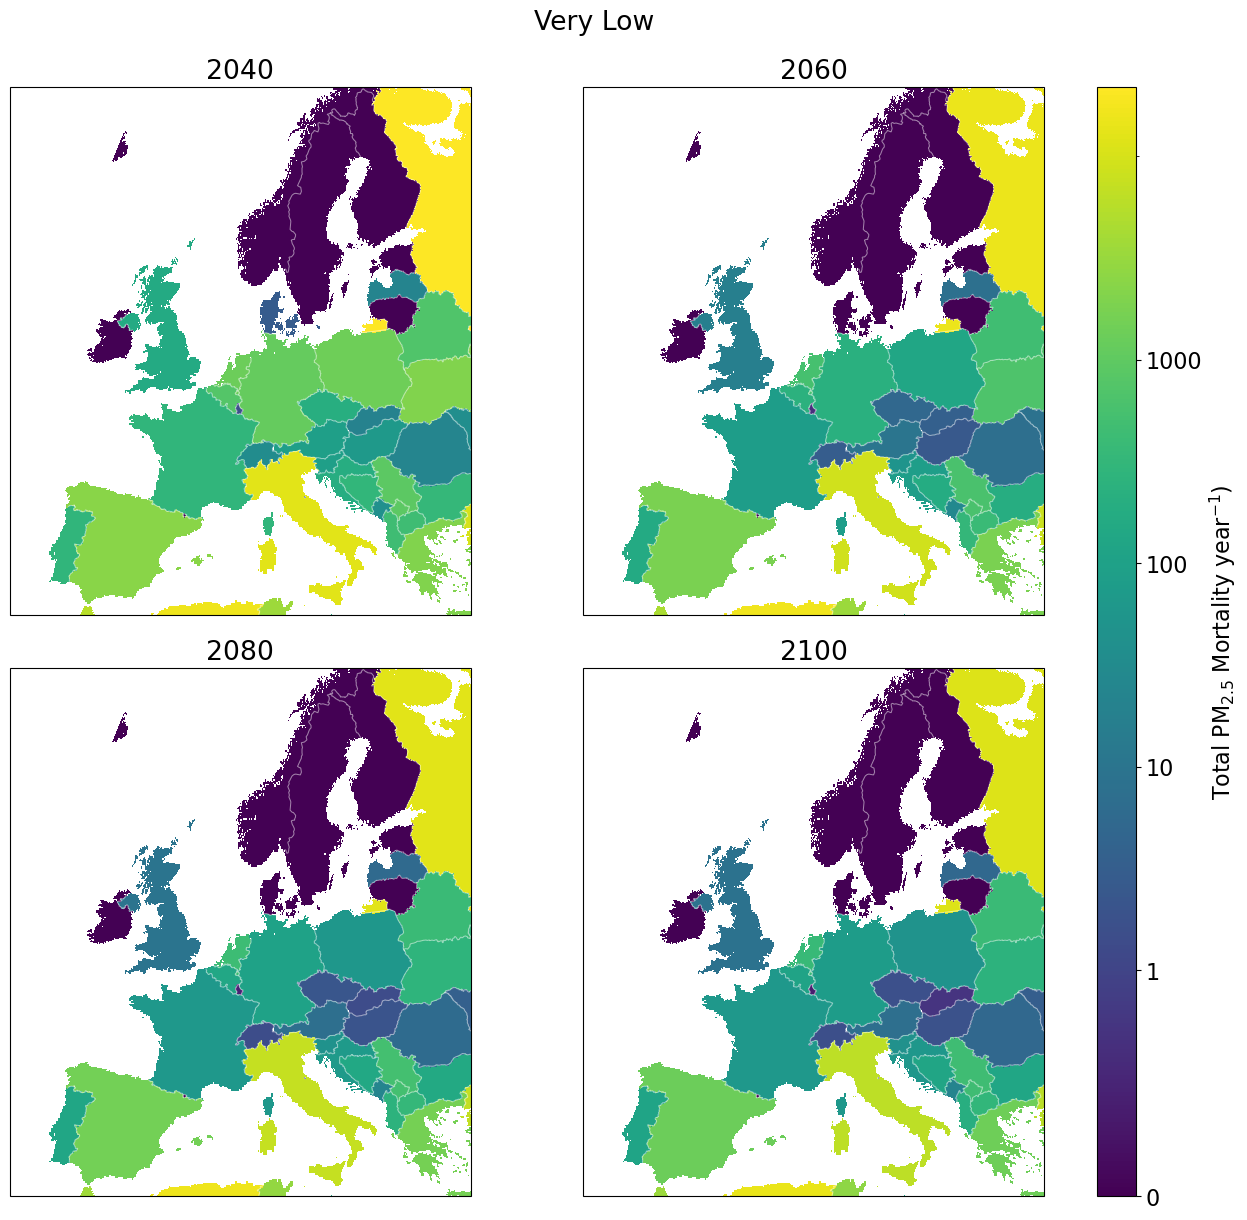

In [9]:
MASKS_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "BMR" / "masks" / "country", "country masks")
SAVE_DIR = require_dir(pathlib.Path(config.PLOTTING_ROOT) / "mortality" / "pm25" / "scenario")

for scenario, scen_name in zip(scenarios, scenario_longname):
    das = [get_mortality(scenario, year, GBD_version) for year in years]
    # convert to eu map
    das_map = [create_eu_country_map(da, MASKS_DIR) for da in das]
    plt.rcParams.update({'font.size': 16})
    plot_mortality_grid(das_map, scenario, scen_name, GBD_version, years, SAVE_DIR)